In [1]:
import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import seaborn as sns
import math
import gzip
import pickle

sys.path.append('./../')
import helpers as hp


pd.options.mode.chained_assignment = None
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "savefig.dpi": 300
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

sns.set_style('ticks', {'font.family': 'Times New Roman', 'font.serif': 'Times New Roman'})
sns.set_context('paper', font_scale=2.0)


colors = plt.cm.tab10.colors
color_map = {
    'SM': 'gray',
    'VLF': colors[2],
    'Scalar': colors[0],
    'Zprime': colors[3],
    'Zprime_20pc': 'firebrick',
    'FakeData': 'black'
}


# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "blue", "VLF": "green", "Zprime": "red"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}



plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['figure.max_open_warning'] = 50
pd.option_context('display.max_columns', -1)


pd.options.mode.chained_assignment = None #Disable copy warnings


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.9, rc={
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.title_fontsize": 14,
    "legend.fontsize": 13,
})
cm = plt.colormaps['RdYlBu']

 # Load the data, perform the best fit for the mass and signal strength per systematic value

In [24]:



systematics = [0.00]
luminosities = np.array([300, 500, 1000, 1500, 2000, 2500, 3000])

# Available options: 'Zprime_3000', 'Scalar_1500', 'VLF_1500'
active_fake_data = 'Scalar_1500'

fitted_data_by_lumi = {}
for lum in luminosities:
    print(f"Processing fits for lumi = {lum} fb-1")
    fitted_data_by_lumi[lum] = hp.fit_and_assemble_data(
        fake_data_key=active_fake_data,
        workspace_file='pT_mass_scan_hists.pkl', #'mass_scan_hists.pkl', #Here you must switch the files for pT and m_ttbar
        sys_err_list=systematics,
        lumi=lum,
        observable = 'pT', #Here you select pT or mTT
        analysis_range = (400, 3600) #Gere you select the interval in order to neglect the negative interference of the Scalar model
    )


Processing fits for lumi = 300 fb-1

Fitting observable: pT
Analysis range: 400 <= pT < 3600 GeV
Systematic error: 0.0%
VLF         : grid mass = 1700.0 GeV | parabolic estimate = 1687.0 GeV | scale = 4.19302 | min q = 1.295
Scalar      : grid mass = 1500.0 GeV | parabolic estimate = 1506.5 GeV | scale = 7.50922 | min q = 0.003
Zprime      : grid mass = 2100.0 GeV | parabolic estimate = 2100.5 GeV | scale = -0.281206 | min q = 12.164
Zprime_20pc : grid mass = 2900.0 GeV | parabolic estimate = 2867.9 GeV | scale = -3.74148 | min q = 5.963
FakeData    : nominal mass = 1500.0 GeV | scale = 7.5
Synthetic signal yield in fit window: 2265.72 events
Processing fits for lumi = 500 fb-1

Fitting observable: pT
Analysis range: 400 <= pT < 3600 GeV
Systematic error: 0.0%
VLF         : grid mass = 1700.0 GeV | parabolic estimate = 1687.0 GeV | scale = 4.19268 | min q = 2.158
Scalar      : grid mass = 1500.0 GeV | parabolic estimate = 1506.6 GeV | scale = 7.50767 | min q = 0.006
Zprime      : grid 

# Plot the best fit distributions

SM 1856744.1676439818
Scalar (Best Fit) 3738.932849754308
VLF (Best Fit) 5084.607950172025
$Z^\prime$ Narrow (Best Fit) 944.1659393946643
$Z^\prime$ Broad (Best Fit) 1380.947724692503
Plot saved successfully as: Dists_ScalarAsimov.png


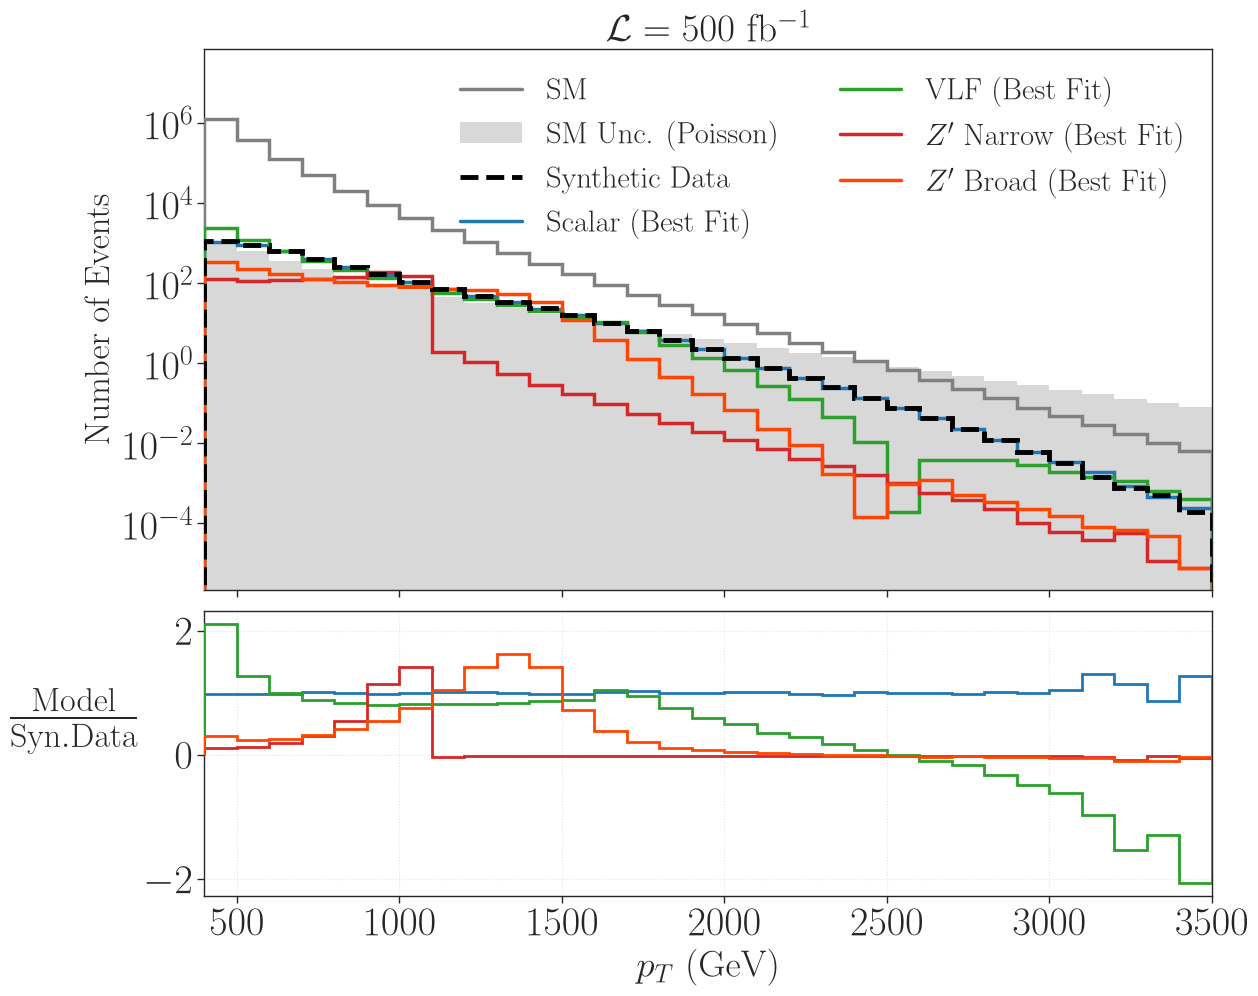

In [27]:
def plot_raw_weighted_histograms_lite(fit_data, lum=3000.0, sys_err=0.0, var="m_tt", rng=(1200, 5000), density=False):
    """
    Plots best-fit distributions and ratios directly from pre-binned histograms
    using matplotlib's `ax.stairs`.
    """
    hists = fit_data['hists']
    raw_bin_edges = np.array(fit_data['bins'])

    # Filter bins and bin edges according to rng
    bin_centers = 0.5 * (raw_bin_edges[:-1] + raw_bin_edges[1:])
    bin_mask = (bin_centers >= rng[0]) & (bin_centers <= rng[1])

    selected_left_edges = raw_bin_edges[:-1][bin_mask]
    selected_right_edge = raw_bin_edges[1:][bin_mask][-1:]
    bin_edges = np.concatenate([selected_left_edges, selected_right_edge])

    colors = plt.cm.tab20.colors
    color_map = {
        'SM': 'gray',
        'VLF (Best Fit)': colors[4],
        'Scalar (Best Fit)': colors[0],
        'Zprime': colors[6],
        'Zprime_20pc': 'orangered',
        'FakeData': 'black',
        r'$Z^\prime$ Broad (Best Fit)': 'orangered',
        r'$Z^\prime$ Narrow (Best Fit)': colors[6],
        'Pseudo Dataset': 'black'
    }

    hist_data = {}

    #  Process SM
    h_sm = hists['SM'][bin_mask] * lum * 1000.0
    hErr_sm_poisson = np.sqrt(np.abs(h_sm))
    hErr_sm = np.sqrt(np.abs(h_sm) + (sys_err * h_sm)**2)
    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'err_poisson': hErr_sm_poisson, 'lbl': "SM"}

    # Process BSM & FakeData Models
    target_models = ['FakeData', 'Scalar', 'VLF', 'Zprime', 'Zprime_20pc']

    for model_key in target_models:
        if model_key not in hists:
            continue

        # Combine pure cross-section + interference (if present) and convert to yield
        h_xsec = hists[model_key][bin_mask].copy()
        if f"{model_key}_int" in hists:
            h_xsec += hists[f"{model_key}_int"][bin_mask]

        h = h_xsec * lum * 1000.0
        err = np.sqrt(np.abs(h))

        # Map display labels
        if model_key == 'Zprime_20pc':
            display_lbl = r'$Z^\prime$ Broad (Best Fit)'
        elif model_key == 'Zprime':
            display_lbl = r'$Z^\prime$ Narrow (Best Fit)'
        elif model_key == 'Scalar':
            display_lbl = 'Scalar (Best Fit)'
        elif model_key == 'VLF':
            display_lbl = 'VLF (Best Fit)'
        else:
            display_lbl = 'FakeData'

        hist_data[display_lbl] = {'h': h, 'err': err, 'lbl': display_lbl, 'raw_key': model_key}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(13, 11), sharex=True,
                                            gridspec_kw={'height_ratios': [1.9, 1], 'hspace': 0.05})

    for lab_str, data in hist_data.items():
        c = color_map.get(lab_str, color_map.get(data.get('raw_key'), 'gray'))

        if data.get('raw_key') == 'FakeData':
            ax_main.stairs(np.abs(data['h']), bin_edges, linewidth=3.5, linestyle='--',
                           label='Synthetic Data', color='black', zorder=4)
        else:
            ax_main.stairs(np.abs(data['h']), bin_edges, linewidth=2.5,
                           label=data['lbl'], color=c, zorder=3)
            print(data['lbl'], np.sum(data['h']))#/(1000*lum))

        # Draw SM Shaded Poisson Uncertainty Band
        if lab_str == 'SM':
            ax_main.stairs(data['err_poisson'], bin_edges, fill=True,
                           color=c, alpha=0.3, zorder=2, label=r"SM Unc. (Poisson)")

        # RATIO PANEL: Ratio of Model / FakeData
        if lab_str != 'FakeData' and 'FakeData' in hist_data:
            h_base = hist_data['FakeData']['h']

           
            ratio = data['h'] / h_base

            if lab_str != 'SM':
                ax_ratio.stairs(ratio, bin_edges, linewidth=2.0, color=c, alpha=1.0, zorder=3)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    ax_main.set_title(rf" $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=28, pad=0)
    ax_main.set_ylabel("Density" if density else "Number of Events", fontsize=25)
    
    # Legend anchored above axes
    ax_main.legend(loc='upper right', framealpha=0.0, fontsize=22, ncols=2)
    #v
    #ax_main.set_yscale('symlog', linthresh=1e-4)
    ax_main.set_yscale('log')
    ax_main.set_ylim([0, 7e+7])
    ax_main.set_xlim([rng[0], rng[1]])
    #ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_main.tick_params(axis='both', width=1,labelsize=29)

    ax_ratio.set_xlabel(r'$p_T$ (GeV)' if var == 'pT' else var, fontsize=27)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{Syn. Data}}$", fontsize=35, rotation=0, labelpad=50)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)

    #Scalar limits
    #ax_ratio.set_ylim([-0.01, 3.2])
    #ax_ratio.set_yticks([0, 1, 2, 3])

    # VLF limits
    #ax_ratio.set_ylim([-.5, 4.2])
    #ax_ratio.set_yticks([ 0, 1, 2, 3, 4])

    #Zprime limits
    #ax_ratio.set_ylim([-1.0,10.2])
    #ax_ratio.set_yticks([   -2, 0, 2, 4,6,8, 10])
    
    ax_ratio.set_xticks(np.arange(500, 3600, 500))
    ax_ratio.tick_params(axis='both',width=1, labelsize=29)

    plt.tight_layout()
    filename = f'Dists_{active_fake_data.split('_')[0]}Asimov.png'
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as: {filename}")
    plt.show()

# ------------------------------------------------------------
# Execution Block
# ------------------------------------------------------------
lumi = 500
sys = 0.00

fit_data = fitted_data_by_lumi[lumi][sys]

plot_raw_weighted_histograms_lite(
    fit_data=fit_data,
    lum=lumi,
    sys_err=sys,
    var="pT",
    rng=(400, 3500),
    density=False
)

# Luminosity scan and significances

In [28]:
#  Run the scanning engine using the nested dictionary
results_df = hp.run_fast_lumi_scan(
    fitted_data_by_lumi=fitted_data_by_lumi,
    labels=["Scalar", "VLF", "Zprime", "Zprime_20pc", 'SM'],
    bin_width=100,
    lumi_targets=luminosities,
    sys_err_list=systematics,
    fake_model='FakeData',
    sm_cms=False,
    analysis_range = (400, 3500)
)



In [29]:
def plot_lumi_syst_combined(results, eps_values, metric="sh", outfile=None, excl_stats=False, fake_model='FakeData', best_fits=None):
    """Generates a single combined plot displaying significance Z-scores as a function of projected luminosity for all models."""

    # --- Color and Style Mapping ---
    colors_tab = plt.cm.tab20.colors
    color_map = {
        'SM': 'gray',
        'VLF': colors_tab[4],
        'Scalar': colors_tab[0],
        'Zprime': colors_tab[6],
        'Zprime_20pc': 'orangered',
        'FakeData': 'black',
        '$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.2)$': 'orangered',
        '$Z^\prime$ $(\Gamma_{Z^\prime}/M_{Z^\prime} = 0.01)$': colors_tab[6],
        'Pseudo Dataset': 'black'
    }

    # Use line styles for systematics since color is used for models
    syst_ls = {0.00: "-", 0.02: "--", 0.05: "-.", 0.10: ":"}

    fig, ax = plt.subplots(figsize=(8, 8))

    pairs = list(results["pair"].unique())
    method_name = "Standard Shape Method" if metric == "sh" else "Normalized Falloff Method"

    for pair in pairs:
        sub = results[results["pair"] == pair].sort_values("lumi")
        eps_v = eps_values[1:] if excl_stats else eps_values


        bsm_name = pair.split(" vs ")[-1] if " vs " in pair else pair


        display_name = hp.format_model_label(bsm_name) if 'format_model_label' in globals() else bsm_name

        if display_name == r'Zprime': display_name = r'$Z^\prime$ Narrow'
        if display_name == r'Zprime_20pc': display_name = r'$Z^\prime$ Broad'

        model_color = color_map.get(bsm_name, color_map.get(display_name, "tab:purple"))

        for eps_syst in eps_v:
            col = f"Z_{metric}_eps_{int(100*eps_syst):02d}"
            if col not in sub.columns: continue

            ls = syst_ls.get(eps_syst, "-")
            syst_label = "stat. only" if eps_syst == 0 else rf"{int(100*eps_syst)}\% syst."


            label_str = f"{display_name}"

            ax.plot(sub["lumi"], sub[col], color=model_color,lw = 2.0, linestyle=ls, label=label_str)

    # --- Formatting the Single Axis ---
    ax.set_ylim([0, 14])
    ax.set_xlim([200,3100])
    ax.axhline(3.0, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axhline(5.0, color='black', linestyle=':', alpha=0.6, linewidth=1.5)
    #ax.text(200, 5.2, r'$Z = 5\sigma$', fontsize=18, color='black', 
        #rotation=0, verticalalignment='center')
    #ax.text(100, 3.2, r'$Z = 3\sigma$', fontsize=18, color='black', 
        #rotation=0, verticalalignment='center')

    ax.set_ylabel(r"Asimov Significance $Z$", fontsize = 25)
    ax.set_xlabel(rf"Integrated Luminosity $\mathcal{{L}}$ [fb$^{{-1}}$]", fontsize = 25)

    # --- Legend and Titles ---

    handles, labels_ = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_, handles))

    ax.tick_params(axis = 'both', width = 1, labelsize = 25)
    ax.legend(by_label.values(), by_label.keys(),loc="best", frameon=False, fontsize = 23., ncols=1)
    ax.set_yticks(np.arange(0,15,1))
    fake_model_str = hp.format_model_label(fake_model) if 'format_model_label' in globals() else fake_model
    fig.suptitle(f"Synthetic data underlying model: {fake_model_str}", fontsize = 25)

    plt.tight_layout()

    if outfile is not None:
        fig.savefig(outfile, bbox_inches="tight", dpi=300)
    plt.show()




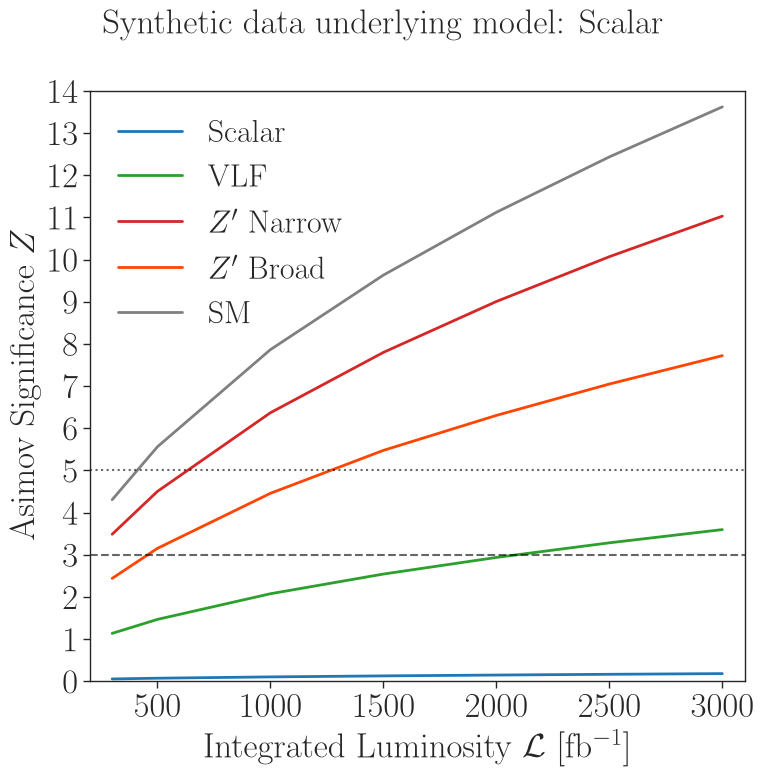

In [30]:
true_model = active_fake_data.split('_')[0]
if 'Zprime' in true_model:
    true_model = r'$Z^\prime$ Broad'
plot_lumi_syst_combined(
    results=results_df,
    eps_values=[0.0],#systematics,
    outfile = f'./AsimovSignificance_vs_Lumi_{active_fake_data.split('_')[0]}.png',
    metric="sh", # "fa" = Falloff Method, "sh" = Shape Method
    fake_model = f'{true_model}'
)

# Summary plot for stats only

In [31]:



sys = [0.00]
lumi = np.array([3000])
dict_Z_HL = {}
# Available options: 'Zprime_3000', 'Scalar_1500', 'VLF_1500'
for fd in ['Scalar_1500', 'VLF_1500', 'Zprime_3000']:
    print(f"Processing fits for lumi = {lumi} fb-1")
    fitted = {}
    fitted[lumi[0]] = hp.fit_and_assemble_data(
        fake_data_key=fd,
        workspace_file='pT_mass_scan_hists.pkl',
        sys_err_list=sys,
        lumi=lumi[0],
        observable = 'pT', #Here you select pT or mTT
        analysis_range = (400, 3600) 
    )
    
    dict_Z_HL[fd] = hp.run_fast_lumi_scan(
    fitted_data_by_lumi=fitted,
    labels=["Scalar", "VLF", "Zprime", "Zprime_20pc", 'SM'],
    bin_width=100,
    lumi_targets=lumi,
    sys_err_list=sys,
    fake_model='FakeData',
    sm_cms=False,
    observable = 'pT', #Here you select pT or mTT
    analysis_range = (400, 3600) 
    )


Processing fits for lumi = [3000] fb-1

Fitting observable: pT
Analysis range: 400 <= pT < 3600 GeV
Systematic error: 0.0%
VLF         : grid mass = 1700.0 GeV | parabolic estimate = 1686.9 GeV | scale = 4.2 | min q = 12.950
Scalar      : grid mass = 1500.0 GeV | parabolic estimate = 1506.5 GeV | scale = 7.50894 | min q = 0.034
Zprime      : grid mass = 2100.0 GeV | parabolic estimate = 2131.3 GeV | scale = -0.281211 | min q = 121.645
Zprime_20pc : grid mass = 2900.0 GeV | parabolic estimate = 2865.7 GeV | scale = -3.74122 | min q = 59.631
FakeData    : nominal mass = 1500.0 GeV | scale = 7.5
Synthetic signal yield in fit window: 22657.17 events
Processing fits for lumi = [3000] fb-1

Fitting observable: pT
Analysis range: 400 <= pT < 3600 GeV
Systematic error: 0.0%
VLF         : grid mass = 1500.0 GeV | parabolic estimate = 1507.0 GeV | scale = 3.49569 | min q = 0.036
Scalar      : grid mass = 1200.0 GeV | parabolic estimate = 1245.0 GeV | scale = 5.31602 | min q = 9.118
Zprime      :

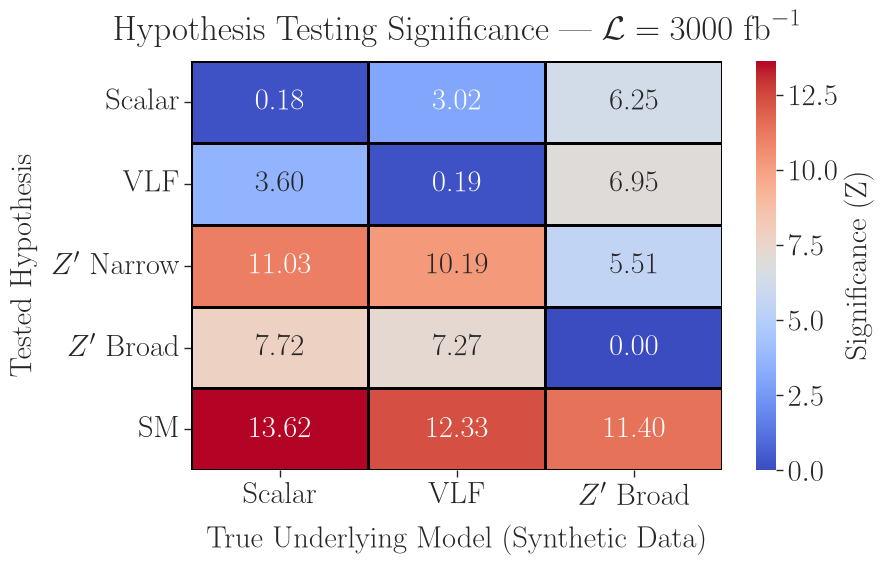

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Label mapping for tested hypothesis rows
model_map = {
    'Scalar': 'Scalar',
    'VLF': 'VLF',
    'Zprime': r'$Z^\prime$ Narrow',
    'Zprime_20pc': r'$Z^\prime$ Broad',
    'SM': 'SM'
}

# 2. Correct mapping for outer synthetic data columns
def clean_outer_key(fd_key):
    if 'Scalar' in fd_key:
        return 'Scalar'
    elif 'VLF' in fd_key:
        return 'VLF'
    elif 'Zprime' in fd_key:
        return r'$Z^\prime$ Broad'  # Fixed: Zprime_3000 is Z' Narrow
    return fd_key

dict_Z = {}

for fd, raw_data in dict_Z_HL.items():
    outer_key = clean_outer_key(fd)
    dict_Z[outer_key] = {}
    
    # Safely extract DataFrame
    if isinstance(raw_data, pd.DataFrame):
        df = raw_data
    elif isinstance(raw_data, dict):
        df_items = [v for v in raw_data.values() if isinstance(v, pd.DataFrame)]
        if df_items:
            df = pd.concat(df_items, ignore_index=True)
        elif 'pair' in raw_data:
            df = pd.DataFrame(raw_data)
        else:
            df = pd.DataFrame([raw_data])
    else:
        continue

    # Explicitly pick shape significance (Z_sh_*) instead of Z_fa_*
    z_sh_cols = [c for c in df.columns if c.startswith('Z_sh')]
    target_col = z_sh_cols[0] if z_sh_cols else 'Z_sh_eps_00'

    # Populate dictionary
    for _, row in df.iterrows():
        if 'pair' in row:
            raw_model = str(row['pair']).split()[-1]
            formatted_model = model_map.get(raw_model, raw_model)
            dict_Z[outer_key][formatted_model] = row[target_col]

# Convert to final DataFrame for heatmap
df_significance = pd.DataFrame(dict_Z)

# Plotting
plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    df_significance,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Significance (Z)'},
    annot_kws={'size': 22},
    linewidths=1,
    linecolor='black'
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22)
cbar.set_label('Significance (Z)', fontsize=22)

plt.tick_params(labelsize=22)
plt.title(r"Hypothesis Testing Significance | $\mathcal{L} = 3000~\rm{fb}^{-1}$", pad=15, fontsize=25)
plt.xlabel("True Underlying Model (Synthetic Data)", labelpad=10, fontsize=22)
plt.ylabel("Tested Hypothesis", labelpad=10, fontsize=22)

plt.tight_layout()
plt.savefig('Summary_plot_stats.png', bbox_inches="tight", dpi=300)
plt.show()